In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importaçao de Bibliotecas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
import seaborn as sns
import zipfile
import requests
from io import BytesIO
import shutil
from PIL import Image
import random

# Configuração do dispositivo (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nome da GPU: {torch.cuda.get_device_name(0)}")

Usando dispositivo: cpu
CUDA disponível: False


# 2: Configuração dos Caminhos do Dataset

In [ ]:
# Configurar caminhos do dataset
base_data_path = "/content/drive/MyDrive/Colab Notebooks/Atividades Pos graduaçao/imagens_processamento/Pedestrians-Dataset"
pedestre_path = os.path.join(base_data_path, "Pedestrians")
background_path = os.path.join(base_data_path, "Background")

# Verificar se o dataset existe
if os.path.exists(base_data_path):
    print(f"✅ Dataset encontrado em: {base_data_path}")
    print(f"📁 Pastas encontradas:")
    for folder in os.listdir(base_data_path):
        folder_path = os.path.join(base_data_path, folder)
        if os.path.isdir(folder_path):
            num_files = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"   - {folder}: {num_files} imagens")
else:
    print(f"❌ Dataset não encontrado em: {base_data_path}")
    print("Por favor, ajuste o caminho do dataset.")

✅ Dataset encontrado em: /content/drive/MyDrive/Colab Notebooks/Atividades Pos graduaçao/imagens_processamento/Pedestrians-Dataset
📁 Pastas encontradas:
   - Pedestrians: 1250 imagens
   - Background: 2990 imagens


# 3: Definir Transformações de Dados

In [ ]:
# Definir transformações para treino e validação/teste
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 64)),           # Redimensionar para 128x64
        transforms.RandomHorizontalFlip(p=0.5), # Flip horizontal aleatório
        transforms.RandomRotation(10),          # Rotação aleatória ±10°
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variação de cor
        transforms.ToTensor(),                  # Converter para tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalização ImageNet
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((128, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

print("🔄 Transformações definidas:")
print("Treino: Redimensionamento + Aumentação de dados + Normalização")
print("Validação/Teste: Redimensionamento + Normalização")

🔄 Transformações definidas:
Treino: Redimensionamento + Aumentação de dados + Normalização
Validação/Teste: Redimensionamento + Normalização


#4: Carregar e Dividir o Dataset

In [ ]:
# Carregar o dataset completo
full_dataset = datasets.ImageFolder(root=base_data_path)
class_names = full_dataset.classes
class_to_idx = full_dataset.class_to_idx

print(f"📊 Informações do Dataset:")
print(f"Classes encontradas: {class_names}")
print(f"Mapeamento de classes: {class_to_idx}")
print(f"Total de imagens: {len(full_dataset)}")

# Dividir o dataset (70% treino, 15% validação, 15% teste)
dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(dataset_size),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Para reprodutibilidade
)

# Criar subsets com transformações específicas
train_dataset = Subset(datasets.ImageFolder(root=base_data_path, transform=data_transforms['train']), train_indices.indices)
val_dataset = Subset(datasets.ImageFolder(root=base_data_path, transform=data_transforms['val_test']), val_indices.indices)
test_dataset = Subset(datasets.ImageFolder(root=base_data_path, transform=data_transforms['val_test']), test_indices.indices)

print(f"\n📈 Divisão do Dataset:")
print(f"Treino: {len(train_dataset)} imagens ({len(train_dataset)/dataset_size*100:.1f}%)")
print(f"Validação: {len(val_dataset)} imagens ({len(val_dataset)/dataset_size*100:.1f}%)")
print(f"Teste: {len(test_dataset)} imagens ({len(test_dataset)/dataset_size*100:.1f}%)")

📊 Informações do Dataset:
Classes encontradas: ['Background', 'Pedestrians']
Mapeamento de classes: {'Background': 0, 'Pedestrians': 1}
Total de imagens: 4240

📈 Divisão do Dataset:
Treino: 2968 imagens (70.0%)
Validação: 636 imagens (15.0%)
Teste: 636 imagens (15.0%)


# 5: Criar DataLoaders

In [ ]:
# Configurar DataLoaders
batch_size = 32
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"🔄 DataLoaders criados:")
print(f"Batch size: {batch_size}")
print(f"Número de batches - Treino: {len(train_loader)}, Validação: {len(val_loader)}, Teste: {len(test_loader)}")

🔄 DataLoaders criados:
Batch size: 32
Número de batches - Treino: 93, Validação: 20, Teste: 20


# 6: Visualizar Amostras do Dataset

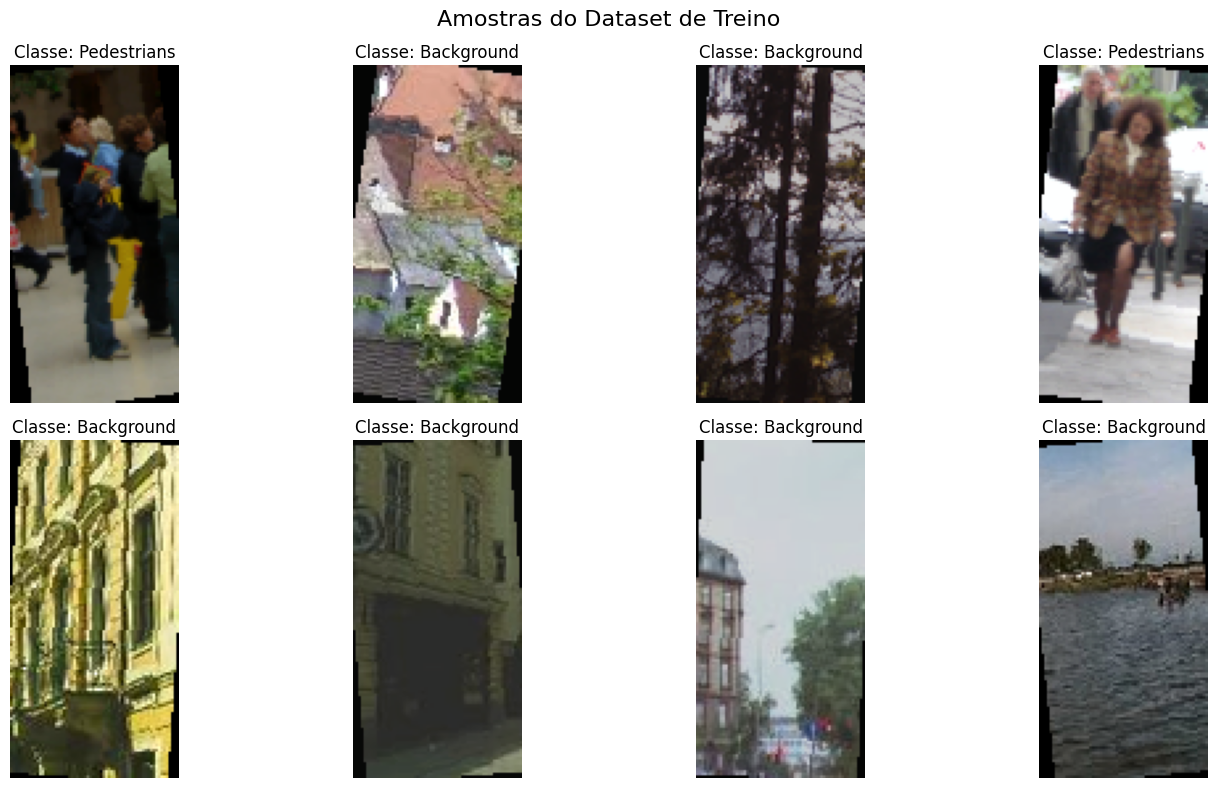

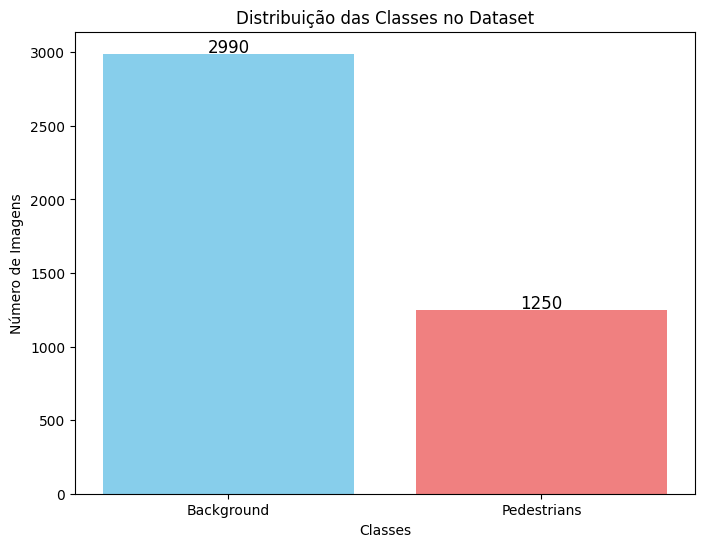

In [ ]:
# Visualizar algumas imagens de exemplo
def denormalize_image(tensor):
    """Desnormaliza um tensor de imagem para visualização"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    tensor = tensor.numpy().transpose((1, 2, 0))
    tensor = std * tensor + mean
    tensor = np.clip(tensor, 0, 1)
    return tensor

# Pegar um batch de treino
images, labels = next(iter(train_loader))

# Plotar 8 imagens
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

for i in range(8):
    img = denormalize_image(images[i])
    axes[i].imshow(img)
    axes[i].set_title(f"Classe: {class_names[labels[i]]}", fontsize=12)
    axes[i].axis('off')

plt.suptitle('Amostras do Dataset de Treino', fontsize=16)
plt.tight_layout()
plt.show()

# Estatísticas das classes
class_counts = {}
full_dataset_for_stats = datasets.ImageFolder(root=base_data_path)
for _, label in full_dataset_for_stats:
    class_name = class_names[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

plt.figure(figsize=(8, 6))
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue', 'lightcoral'])
plt.title('Distribuição das Classes no Dataset')
plt.ylabel('Número de Imagens')
plt.xlabel('Classes')
for i, (class_name, count) in enumerate(class_counts.items()):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.show()

# 7: Definir a Arquitetura da CNN

In [ ]:
class PedestrianCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(PedestrianCNN, self).__init__()

        # Primeira camada convolucional
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Segunda camada convolucional
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Terceira camada convolucional
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout_conv = nn.Dropout(0.25)

        # Camadas totalmente conectadas
        self.flattened_size = 64 * 16 * 8  # 64 canais * 16 altura * 8 largura
        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.relu4 = nn.ReLU()
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Camadas convolucionais
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.dropout_conv(x)

        # Achatar para camadas FC
        x = x.view(-1, self.flattened_size)
        x = self.relu4(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)

        return x

# Instanciar o modelo
model = PedestrianCNN(num_classes=len(class_names)).to(device)

# Visualizar a arquitetura
print("🏗️ Arquitetura da CNN:")
print(model)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Parâmetros do modelo:")
print(f"Total: {total_params:,}")
print(f"Treináveis: {trainable_params:,}")

🏗️ Arquitetura da CNN:
PedestrianCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

📊 Parâmetros do modelo:
Total: 4,219,426
Treináveis: 4,219,426


# 8: Configurar Treinamento

In [ ]:
# Definir função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Configurações de treinamento
num_epochs = 25
print(f"⚙️ Configurações de Treinamento:")
print(f"Épocas: {num_epochs}")
print(f"Otimizador: Adam (lr=0.001)")
print(f"Função de perda: CrossEntropyLoss")
print(f"Scheduler: StepLR (step_size=7, gamma=0.1)")

⚙️ Configurações de Treinamento:
Épocas: 25
Otimizador: Adam (lr=0.001)
Função de perda: CrossEntropyLoss
Scheduler: StepLR (step_size=7, gamma=0.1)


# 9: Loop de Treinamento

In [ ]:
# Listas para armazenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0

print("🚀 Iniciando treinamento...")
print("=" * 80)

for epoch in range(num_epochs):
    # FASE DE TREINAMENTO
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Mostrar progresso a cada 30 batches
        if batch_idx % 30 == 0:
            print(f'Época {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # FASE DE VALIDAÇÃO
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # Atualizar scheduler
    scheduler.step()

    # Salvar melhor modelo
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_pedestrian_cnn_weights.pth")
        print(f"🎯 Novo melhor modelo salvo! Acurácia de validação: {best_val_acc:.4f}")

    print(f"Época [{epoch+1}/{num_epochs}]")
    print(f"Treino - Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"Validação - Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")
    print("-" * 50)

print("✅ Treinamento concluído!")

🚀 Iniciando treinamento...
Época 1/25, Batch 0/93, Loss: 0.6955
Época 1/25, Batch 30/93, Loss: 0.5457
Época 1/25, Batch 60/93, Loss: 0.3349
Época 1/25, Batch 90/93, Loss: 0.2504
🎯 Novo melhor modelo salvo! Acurácia de validação: 0.9167
Época [1/25]
Treino - Loss: 0.4957, Acc: 0.7537
Validação - Loss: 0.2161, Acc: 0.9167
--------------------------------------------------
Época 2/25, Batch 0/93, Loss: 0.2134
Época 2/25, Batch 30/93, Loss: 0.1991
Época 2/25, Batch 60/93, Loss: 0.1221
Época 2/25, Batch 90/93, Loss: 0.3118
🎯 Novo melhor modelo salvo! Acurácia de validação: 0.9292
Época [2/25]
Treino - Loss: 0.2235, Acc: 0.9097
Validação - Loss: 0.1604, Acc: 0.9292
--------------------------------------------------
Época 3/25, Batch 0/93, Loss: 0.0899
Época 3/25, Batch 30/93, Loss: 0.2459
Época 3/25, Batch 60/93, Loss: 0.0145


# 10: Visualizar Histórico de Treinamento

In [ ]:
# Plotar histórico de treinamento
plt.figure(figsize=(15, 5))

# Subplot 1: Perda
plt.subplot(1, 3, 1)
plt.plot(train_losses, 'b-', label='Treino', linewidth=2)
plt.plot(val_losses, 'r-', label='Validação', linewidth=2)
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Acurácia
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, 'b-', label='Treino', linewidth=2)
plt.plot(val_accuracies, 'r-', label='Validação', linewidth=2)
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Taxa de aprendizado
plt.subplot(1, 3, 3)
lrs = [0.001 * (0.1 ** (epoch // 7)) for epoch in range(num_epochs)]
plt.plot(lrs, 'g-', linewidth=2)
plt.title('Taxa de Aprendizado')
plt.xlabel('Época')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estatísticas finais
print(f"📊 Resultados do Treinamento:")
print(f"Melhor acurácia de validação: {best_val_acc:.4f}")
print(f"Acurácia final de treino: {train_accuracies[-1]:.4f}")
print(f"Acurácia final de validação: {val_accuracies[-1]:.4f}")

# 11: Avaliação no Conjunto de Teste

In [ ]:
# Carregar o melhor modelo
model.load_state_dict(torch.load("best_pedestrian_cnn_weights.pth"))
model.eval()

print("🧪 Avaliando no conjunto de teste...")

all_labels_test = []
all_predictions_test = []
all_probs_test = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        all_labels_test.extend(labels.cpu().numpy())
        all_predictions_test.extend(predicted.cpu().numpy())
        all_probs_test.extend(probs.cpu().numpy())

# Calcular métricas
accuracy_test = accuracy_score(all_labels_test, all_predictions_test)

# Definir classe positiva (Pedestrians)
pos_label_idx = class_to_idx.get('Pedestrians', 1)
precision_test = precision_score(all_labels_test, all_predictions_test, pos_label=pos_label_idx, average='binary')
recall_test = recall_score(all_labels_test, all_predictions_test, pos_label=pos_label_idx, average='binary')
f1_test = f1_score(all_labels_test, all_predictions_test, pos_label=pos_label_idx, average='binary')

print(f"\n📈 Desempenho no Conjunto de Teste:")
print(f"Acurácia: {accuracy_test:.4f}")
print(f"Precisão: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")

#  12: Matriz de Confusão e Análise Detalhada

In [ ]:
# Matriz de confusão
cm_test = confusion_matrix(all_labels_test, all_predictions_test)

plt.figure(figsize=(12, 5))

# Subplot 1: Matriz de confusão
plt.subplot(1, 2, 1)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Número de Amostras'})
plt.xlabel('Rótulos Preditos')
plt.ylabel('Rótulos Verdadeiros')
plt.title('Matriz de Confusão - Conjunto de Teste')

# Subplot 2: Métricas por classe
plt.subplot(1, 2, 2)
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
values = [accuracy_test, precision_test, recall_test, f1_test]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightyellow']

bars = plt.bar(metrics, values, color=colors)
plt.title('Métricas de Avaliação')
plt.ylabel('Score')
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Análise detalhada da matriz de confusão
tn, fp, fn, tp = cm_test.ravel()
print(f"\n🔍 Análise Detalhada da Matriz de Confusão:")
print(f"Verdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")
print(f"\nTaxa de Falsos Positivos: {fp/(fp+tn):.4f}")
print(f"Taxa de Falsos Negativos: {fn/(fn+tp):.4f}")

# 13: Teste com Imagem Aleatória

In [ ]:
def predict_single_image(image_path, model, class_names, transform):
    """Função para predizer uma única imagem"""
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)
            predicted_class = class_names[predicted_idx.item()]

        return image, predicted_class, confidence.item()
    except Exception as e:
        print(f"Erro ao processar imagem: {e}")
        return None, None, None

print("🎯 Teste com Imagem Aleatória")

# Coletar todos os caminhos de imagem
all_image_paths = []
true_labels_for_paths = []

for class_name in class_names:
    class_folder = os.path.join(base_data_path, class_name)
    if os.path.exists(class_folder):
        for img_name in os.listdir(class_folder):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(class_folder, img_name)
                all_image_paths.append(img_path)
                true_labels_for_paths.append(class_name)

if all_image_paths:
    # Selecionar múltiplas imagens aleatórias
    num_samples = 6
    random_indices = random.sample(range(len(all_image_paths)), min(num_samples, len(all_image_paths)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for i, idx in enumerate(random_indices):
        random_image_path = all_image_paths[idx]
        true_label = true_labels_for_paths[idx]

        original_image, predicted_class, confidence = predict_single_image(
            random_image_path, model, class_names, data_transforms['val_test']
        )

        if original_image:
            axes[i].imshow(original_image)

            # Determinar cor do título baseado na predição
            color = 'green' if predicted_class == true_label else 'red'
            axes[i].set_title(f'Real: {true_label}\nPred: {predicted_class}\nConf: {confidence:.3f}',
                            color=color, fontsize=11, fontweight='bold')
            axes[i].axis('off')

    plt.suptitle('Predições em Imagens Aleatórias', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Calcular acurácia nas amostras testadas
    correct_predictions = sum(1 for i, idx in enumerate(random_indices)
                            if predict_single_image(all_image_paths[idx], model, class_names,
                                                   data_transforms['val_test'])[1] == true_labels_for_paths[idx])

    print(f"Acurácia nas {len(random_indices)} amostras testadas: {correct_predictions}/{len(random_indices)} = {correct_predictions/len(random_indices)*100:.1f}%")
else:
    print("Nenhuma imagem encontrada para teste.")

# 14: Salvar Modelo e Resumo Final

In [ ]:
# Salvar modelo final
torch.save(model.state_dict(), "final_pedestrian_cnn_weights.pth")
print("💾 Modelo final salvo como 'final_pedestrian_cnn_weights.pth'")

# Resumo final do projeto
print("\n" + "="*60)
print("📋 RESUMO FINAL DO PROJETO")
print("="*60)
print(f"🎯 Objetivo: Classificação de Pedestres vs Background")
print(f"📊 Dataset: {len(full_dataset)} imagens totais")
print(f"🏗️ Arquitetura: CNN Customizada com {trainable_params:,} parâmetros")
print(f"⚡ Dispositivo: {device}")
print(f"🔄 Épocas de treinamento: {num_epochs}")
print(f"\n📈 RESULTADOS FINAIS:")
print(f"   • Melhor acurácia de validação: {best_val_acc:.4f}")
print(f"   • Acurácia no teste: {accuracy_test:.4f}")
print(f"   • Precisão: {precision_test:.4f}")
print(f"   • Recall: {recall_test:.4f}")
print(f"   • F1-Score: {f1_test:.4f}")
print("="*60)


In [ ]:
# Função para carregar o modelo posteriormente
#print(f"\n💡 Para carregar o modelo posteriormente:")
#print(f"model = PedestrianCNN(num_classes={len(class_names)})")
#print(f"model.load_state_dict(torch.load('best_pedestrian_cnn_weights.pth'))")
#print(f"model.eval()")